# Depuración de la matriz completa · TFM Energía UCM

Segundo notebook de depuración. El primero (`03_depuracion_variables.ipynb`) trabaja
sobre la variante `sin_2020` del v5, que **ya venía filtrada** por el constructor:
poda de redundantes, filtro de tendencias, capacidad convertida a cuota y la semana
del apagón borrada. Depurar sobre eso es depurar lo ya depurado, sin ver qué se cayó
por el camino ni por qué.

Este notebook parte de **`dataset_horario_v04.csv`**, la matriz sin podar: 219 columnas,
2020-01-01 → 2026-07-31, con la semana del apagón dentro.

Y la parte "arreglada", en la sección 2: **el bloque `pdbc_*` se retira entero y se
sustituye por el PBF horario**, y **se le añade la meteorología ERA5** que v04 no traía
y las variantes v5 sí. El motivo de las dos cosas está medido allí.

Metodología: la del módulo 06.1 (`Tarea_Eleccionesy_v2.py`), con `funciones_mineria.py`
copiada sin tocar. Cada sección cierra con la tabla de control, para ver la evolución
del dataframe de principio a fin.

## 0 · Configuración y carga

In [1]:
import json
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 150)
pd.set_option("display.width", 220)
plt.rcParams["figure.figsize"] = (12, 5)

REPO = Path("..").resolve()
sys.path.append(str(REPO / "scripts"))

from funciones_mineria import Vcramer                    # librería de clase, sin tocar
import depuracion as dep                                  # adaptaciones a serie horaria
from pbf_horario import bloque_para_matriz as bloque_pbf
from era5_horario import bloque_para_matriz as bloque_era5
from procedencia import (origen, bloque, con_origen, con_origen_pares,
                         resumen_origen, catalogo)

ORIGEN = REPO / "ingesta" / "dt_maestro_sergio" / "dataset_horario_v04.csv"
PBF_PARQUET = REPO / "data" / "bronze" / "pbf_horario.parquet"
ERA5_PARQUET = REPO / "data" / "bronze" / "era5_horario.parquet"
SALIDA_DIR = REPO / "data" / "matrices"
TARGET = "target_price"

# Ventana del apagón ibérico. NO se borra: se marca. La justificación empírica está
# en la sección 2.4 -- es la propia ausencia de publicación del PBF quien la delimita.
APAGON_INI, APAGON_FIN = pd.Timestamp("2025-04-28"), pd.Timestamp("2025-05-06")

# Banderas: metadatos de la fila, no features. Se excluyen del recuento de
# perdidos porque `target_contrafactual` es NaN por diseño fuera del apagón.
COLS_BANDERA_PREVIAS = ["dia_apagon", "ventana_pisa_apagon", "target_contrafactual"]

### Protocolo de cierre del equipo

De la instrucción de Amgui, y condiciona todo lo que sigue:

> Entrenad hasta el 31-dic-2024 y validad sobre 2025 completo. **No uséis 2026** — lo
> reservamos como conjunto de test y lo abrimos una sola vez el 31 de agosto.

En este notebook eso se traduce en dos reglas mecánicas:

1. **Todo lo que se decide, se decide sobre `train`** (≤ 31-dic-2024): descriptivos,
   umbrales, qué columna cae y cuál no.
2. **2026 no se lee jamás.** Ni para un descriptivo, ni para una correlación, ni para
   medir deriva. La deriva se mide contra 2025, que es validación. Hay una comprobación
   automática al final que lo verifica.

Las filas de 2026 sí viajan en los ficheros de salida — se necesitan el día 31 —, pero
ninguna decisión de este notebook las ha mirado.

In [2]:
datos = pd.read_csv(ORIGEN, parse_dates=["fecha_pred", "fecha_objetivo"])
datos["ts"] = datos["fecha_objetivo"] + pd.to_timedelta(datos["hora"], unit="h")
datos = datos.sort_values("ts").reset_index(drop=True)

TRAIN = datos["split"] == "train"
VAL = datos["split"] == "validation"
TEST = datos["split"] == "test"          # 2026 -- prohibido mirar

print(f"Origen: {ORIGEN.name}")
print(f"Forma : {datos.shape[0]:,} filas x {datos.shape[1]} columnas\n")
print(datos.groupby("split", sort=False).agg(
    filas=("ts", "size"), dias=("fecha_objetivo", "nunique"),
    desde=("fecha_objetivo", "min"), hasta=("fecha_objetivo", "max")).to_string())

Origen: dataset_horario_v04.csv
Forma : 57,689 filas x 220 columnas

            filas  dias      desde      hasta
split                                        
train       43867  1828 2020-01-01 2025-01-01
validation   8759   365 2025-01-02 2026-01-01
test         5063   211 2026-01-02 2026-07-31


In [3]:
# ── Tabla de control ───────────────────────────────────────────────────────
# El hilo del notebook: qué se llevó por delante cada decisión.
historial = []


def registrar(etapa, df, cols=None):
    cols = list(df.columns) if cols is None else [c for c in cols if c in df.columns]
    historial.append({
        "etapa": etapa,
        "filas": len(df),
        "columnas": len(cols),
        "celdas_nulas": int(df[cols].isna().sum().sum()),
        "filas_con_nulo": int(df[cols].isna().any(axis=1).sum()),
    })
    return pd.DataFrame(historial)


# Registro de cada descarte, con su motivo. Es lo que se lleva a la memoria.
bitacora = []


def anotar(seccion, variable, motivo, detalle=""):
    bitacora.append({"seccion": seccion, "variable": variable,
                     "motivo": motivo, "detalle": detalle})


registrar("0 · carga v04", datos)

,etapa,filas,columnas,celdas_nulas,filas_con_nulo
0,0 · carga v04,57689,220,112026,17012


## 1 · Objetivos

**Variable objetivo:** `target_price` — precio horario del mercado diario español para
el día D+1. Una fila por (día objetivo, hora), `fecha_objetivo = fecha_pred + 1 día`.

Este notebook **no modela**. Produce dos cosas:

- una **bitácora de descartes** con el motivo de cada columna que cae, y
- **2-3 matrices candidatas** para que el equipo elija con qué entrenar.

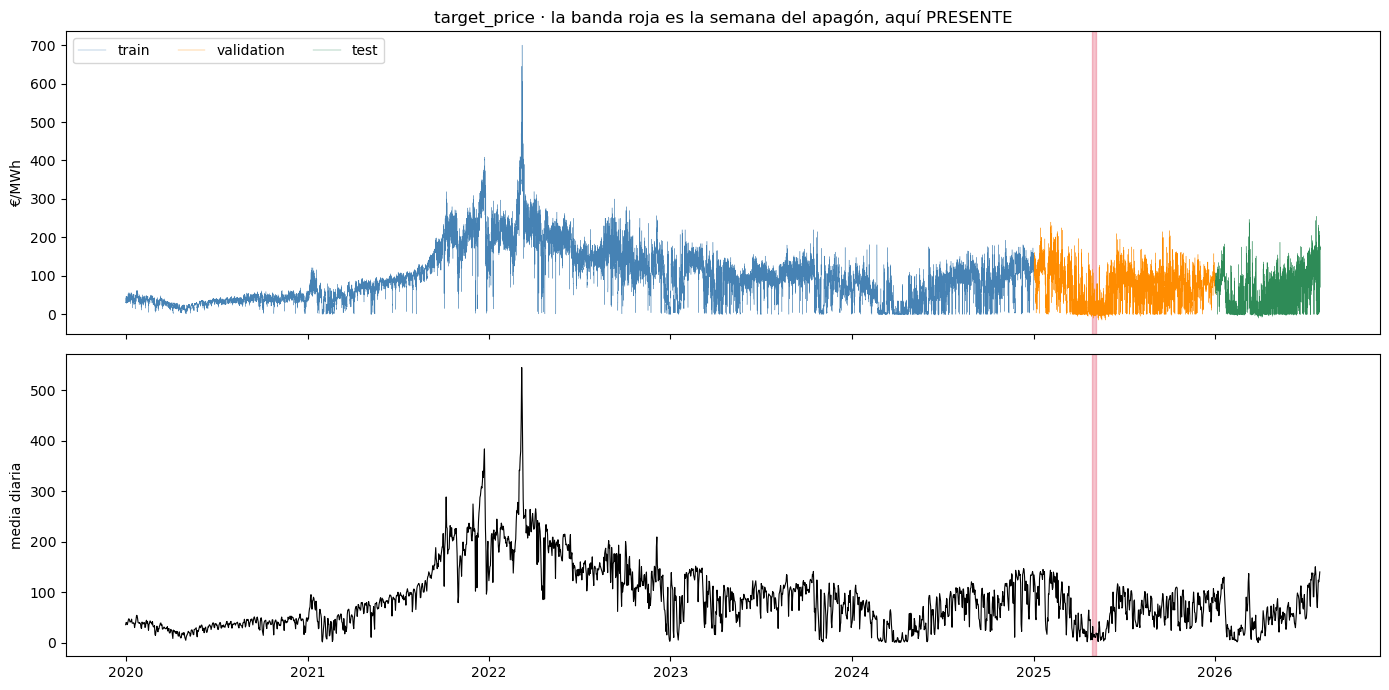

In [4]:
fig, ax = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
for s, color in [("train", "steelblue"), ("validation", "darkorange"), ("test", "seagreen")]:
    sub = datos[datos["split"] == s]
    ax[0].plot(sub["ts"], sub[TARGET], lw=0.25, color=color, label=s)
ax[0].axvspan(APAGON_INI, APAGON_FIN, color="crimson", alpha=0.25)
ax[0].set_ylabel("€/MWh"); ax[0].legend(ncol=3)
ax[0].set_title("target_price · la banda roja es la semana del apagón, aquí PRESENTE")

diario = datos.set_index("ts")[TARGET].resample("D").mean()
ax[1].plot(diario.index, diario.values, lw=0.8, color="black")
ax[1].axvspan(APAGON_INI, APAGON_FIN, color="crimson", alpha=0.25)
ax[1].set_ylabel("media diaria")
plt.tight_layout()

## 2 · Reparación de la matriz

Antes de depurar hay que arreglar dos cosas que vienen mal de origen.

### 2.1 · Fuera el bloque `pdbc_*`

Las 102 columnas `pdbc_*` salen de `esios_pdbc_gen`, una tabla **derivada** (PBF menos
bilaterales, ver `ingesta/refresh_pdbc.py`). Tiene dos defectos, los dos medidos contra
la base de datos:

**Uno — la derivación convierte ceros en nulos.** Cruce hora a hora de las dos tablas:

| | horas |
|---|---:|
| PBF `= 0` y PDBC `NULL` | **34.643** |
| PBF `= 0` y PDBC `= 0` | 89 |
| PBF `< 0` y PDBC `NULL` | **0** |
| PBF `< 0` y PDBC `< 0` | 23.585 |

Ni un caso al revés. Los "nulos" del bombeo eran ceros del PBF perdidos en la resta.

**Dos — se agregaba a media diaria.** El constructor v5 metía el PDBC en el bloque de
"contexto diario" junto a commodities y capacidad (comentario de su línea 1740), porque
ese bloque venía heredado del dataset diario. Pero el PBF es horario y el target es
horario: la media borra el perfil intradiario, que es donde está la señal. Y como
`groupby().mean()` ignora los `NaN`, la "media diaria" del bombeo era en realidad la
media de las horas **con** bombeo: −1.289 frente a los −684 reales, sesgo de 2,4×.

In [5]:
pdbc = [c for c in datos.columns if c.startswith("pdbc_")]
print(f"Columnas pdbc_* en la matriz: {len(pdbc)}")
print(f"  {len(pdbc)} = 17 tecnologías x 3 estadísticos (mean/min/max) x 2 lags (1d/7d)")
print(f"  celdas nulas que aportaban: {datos[pdbc].isna().sum().sum():,}")

datos = datos.drop(columns=pdbc)
for c in pdbc:
    anotar("2.1", c, "bloque PDBC retirado",
           "tabla derivada que convierte ceros en nulos + agregación diaria indebida")

print(f"\nMatriz tras retirar el bloque: {datos.shape[1]} columnas")
registrar("2.1 · fuera PDBC", datos)

Columnas pdbc_* en la matriz: 102
  102 = 17 tecnologías x 3 estadísticos (mean/min/max) x 2 lags (1d/7d)
  celdas nulas que aportaban: 62,352

Matriz tras retirar el bloque: 118 columnas


,etapa,filas,columnas,celdas_nulas,filas_con_nulo
0,0 · carga v04,57689,220,112026,17012
1,2.1 · fuera PDBC,57689,118,49674,7486


### 2.2 · Dentro el PBF horario

`esios_pbf_gen` y `esios_pbf_load_inter` son la fuente sin derivar. Eje horario completo
(58.391 de 58.391 horas, cero huecos), ceros explícitos y una única ausencia real.

**Alineamiento `_D`, no lag.** El PBF del día X se publica a las 13:45 de X-1. Al cerrar
el mercado de D+1 (12:00 del día D) ya está disponible el PBF **del propio día D** —
misma posición que `es_esios_D`. Usar D-1 gastaría un día de frescura sin ganar
seguridad. El PBF de D+1 sí sería fuga: sale de la misma casación que fija el target.

La extracción y la limpieza de convención NULL/0 viven en `scripts/pbf_horario.py`.

In [6]:
pbf = pd.read_parquet(PBF_PARQUET)
bloque = bloque_pbf(pbf, alineamiento="D")

antes = len(datos)
datos = datos.merge(bloque, on=["fecha_pred", "hora"], how="left")
assert len(datos) == antes, "el merge no debe alterar el número de filas"

nuevas = [c for c in datos.columns if c.startswith("pbf_")]
print(f"Bloque PBF incorporado: {len(nuevas)} columnas horarias")
print(f"  filas sin PBF: {datos['pbf_wind_mw_D'].isna().sum()} "
      f"({datos['pbf_wind_mw_D'].isna().mean() * 100:.2f}%)")
print(f"\nMatriz: {datos.shape[0]:,} x {datos.shape[1]}")
registrar("2.2 · +PBF horario", datos)

Bloque PBF incorporado: 32 columnas horarias
  filas sin PBF: 68 (0.12%)

Matriz: 57,689 x 150


,etapa,filas,columnas,celdas_nulas,filas_con_nulo
0,0 · carga v04,57689,220,112026,17012
1,2.1 · fuera PDBC,57689,118,49674,7486
2,2.2 · +PBF horario,57689,150,90048,33879


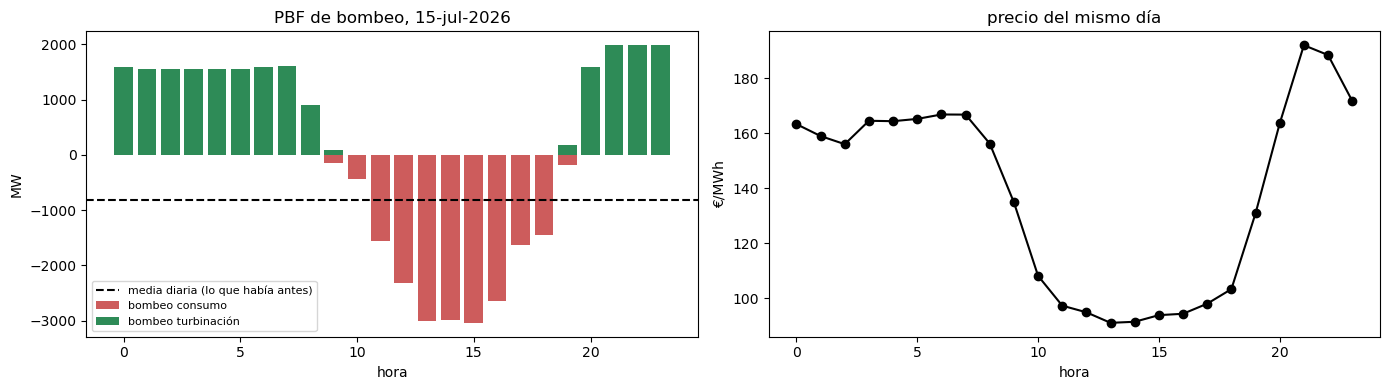

In [7]:
# El perfil intradiario que la media diaria borraba.
dia = datos[datos["fecha_objetivo"] == "2026-07-15"]
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].bar(dia["hora"], dia["pbf_pumping_cons_mw_D"], color="indianred", label="bombeo consumo")
ax[0].bar(dia["hora"], dia["pbf_pumping_gen_mw_D"], color="seagreen", label="bombeo turbinación")
ax[0].axhline(dia["pbf_pumping_cons_mw_D"].mean(), ls="--", color="black",
              label="media diaria (lo que había antes)")
ax[0].set_xlabel("hora"); ax[0].set_ylabel("MW"); ax[0].legend(fontsize=8)
ax[0].set_title("PBF de bombeo, 15-jul-2026")
ax[1].plot(dia["hora"], dia[TARGET], marker="o", color="black")
ax[1].set_xlabel("hora"); ax[1].set_ylabel("€/MWh"); ax[1].set_title("precio del mismo día")
plt.tight_layout()

### 2.3 · Dentro la meteorología ERA5

v04 sale del constructor v4 (23-ago) y no lleva ni una columna de meteo. Las variantes
v5 sí llevan 20, y conviene saber por qué el `meta.json` de esas variantes dice
`"incluir_clima": false` y aun así las tiene: en el constructor hay **dos caminos**
distintos para ERA5 y solo uno responde a ese flag.

| | qué es | lo gobierna |
|---|---|---|
| `_features_clima()` | clima como **contexto diario** | `incluir_clima`, apagado desde el 23-ago |
| `_era5_horario()` | ERA5 **horario** | `ERA5_MODO`, siempre activo en modo `lag` |

Es el segundo el que produce las 20 columnas. La extracción vive en
`scripts/era5_horario.py` y está **validada contra el propio v5**: diferencia máxima
5·10⁻⁵ frente a `dataset_horario_sin_ntc_prev_v01.csv`, que es el redondeo del CSV.

**Frontera de información.** ERA5 es *reanálisis*: el tiempo que realmente ocurrió, no
una previsión. Solo entra con desfase — `met_Dm1` (día D-1) y `met_Dm2` (D-2). El día D
no entra: a las 12:00 de D solo han ocurrido sus horas 00-11, y meterlo entero sería
fuga de medio día.

De las 9 medidas de la tabla salen 10 columnas por desfase, porque la lluvia recibe un
trato aparte: `tp` es un **acumulado**, así que no se interpola como valor puntual sino
que se convierte en ventanas móviles de 7 y 30 días. Esa es la escala a la que la lluvia
mueve la hidráulica, y es de lo poco que ERA5 aporta que no esté ya en las previsiones
de REE.

In [8]:
era5 = pd.read_parquet(ERA5_PARQUET)
bloque_m = bloque_era5(era5)

antes = len(datos)
datos = datos.merge(bloque_m, on=["fecha_objetivo", "hora"], how="left")
assert len(datos) == antes, "el merge no debe alterar el número de filas"

met = [c for c in datos.columns if "_met_Dm" in c]
print(f"Bloque ERA5 incorporado: {len(met)} columnas")
print(f"  filas sin meteo: {datos['t2m_mean_met_Dm1'].isna().sum()} "
      f"(bordes: el 1-ene-2020 necesita ERA5 de 2019, que no está en la tabla)")
print()
print(f"Matriz: {datos.shape[0]:,} x {datos.shape[1]}")
registrar("2.3 · +ERA5 horario", datos)

Bloque ERA5 incorporado: 20 columnas
  filas sin meteo: 56 (bordes: el 1-ene-2020 necesita ERA5 de 2019, que no está en la tabla)

Matriz: 57,689 x 170


,etapa,filas,columnas,celdas_nulas,filas_con_nulo
0,0 · carga v04,57689,220,112026,17012
1,2.1 · fuera PDBC,57689,118,49674,7486
2,2.2 · +PBF horario,57689,150,90048,33879
3,2.3 · +ERA5 horario,57689,170,91408,33882


### 2.4 · El apagón: se marca, no se borra

El constructor v5 **elimina** las filas del 28-abr al 6-may de 2025 y deja el hueco sin
señalar (la columna `dia_excluido` que promete su comentario no existe en el CSV). Eso
tiene dos problemas: la validación deja de ser "2025 completo", y borrar días del medio
rompe la contigüidad de la ventana del encoder sin que nada lo advierta.

Aquí los días se conservan y se marcan con tres banderas. Y la ventana no es una
decisión de despacho: **la delimita el propio dato**. El PBF deja de publicarse a las
12:00 del 28 de abril (el corte fue a las 12:33), no hay programa el 29, y la nuclear
sigue sin publicarse hasta el 4 de mayo.

In [9]:
fo = datos["fecha_objetivo"]
datos["dia_apagon"] = ((fo >= APAGON_INI) & (fo <= APAGON_FIN)).astype(int)

# Para el encoder: una muestra cuya ventana de 7 días pise el apagón está contaminada
# aunque su propio día esté limpio.
dias_apagon = set(datos.loc[datos["dia_apagon"] == 1, "fecha_objetivo"].dt.normalize())
pisa = pd.Series(False, index=datos.index)
for k in range(1, 8):
    pisa |= (fo - pd.Timedelta(days=k)).isin(dias_apagon)
datos["ventana_pisa_apagon"] = (pisa & (datos["dia_apagon"] == 0)).astype(int)

print(f"Días de apagón            : {datos['dia_apagon'].sum() // 24} "
      f"({datos['dia_apagon'].sum()} filas)")
print(f"Días con ventana pisada   : {datos['ventana_pisa_apagon'].sum() // 24} "
      f"({datos['ventana_pisa_apagon'].sum()} filas)")
print(f"Todos dentro de validación: "
      f"{datos.loc[datos['dia_apagon'] == 1, 'split'].unique()}")
print()
print("Testigos del PBF dentro de la ventana:")
sub = datos[datos["dia_apagon"] == 1]
print(f"  horas sin programa publicado : {(sub['pbf_publicado_D'] == 0).sum()}")
print(f"  horas con programa incompleto: "
      f"{((sub['pbf_publicado_D'] == 1) & (sub['pbf_completo_D'] == 0)).sum()}")

Días de apagón            : 9 (216 filas)
Días con ventana pisada   : 7 (168 filas)
Todos dentro de validación: ['validation']

Testigos del PBF dentro de la ventana:
  horas sin programa publicado : 36
  horas con programa incompleto: 82


In [10]:
# Contrafactual: qué habría costado esa semana sin el apagón. Análogo de la semana
# anterior (mismo día de la semana y misma hora) reescalado por el gas, que es el
# driver dominante del precio. NO sustituye al dato real: es una columna aparte.
precio_lag7 = (datos.set_index(["fecha_objetivo", "hora"])[TARGET]
               .rename("p7").reset_index())
precio_lag7["fecha_objetivo"] += pd.Timedelta(days=7)
gas_lag7 = (datos.set_index(["fecha_objetivo", "hora"])["gas_mibgas"]
            .rename("g7").reset_index())
gas_lag7["fecha_objetivo"] += pd.Timedelta(days=7)

datos = datos.merge(precio_lag7, on=["fecha_objetivo", "hora"], how="left")
datos = datos.merge(gas_lag7, on=["fecha_objetivo", "hora"], how="left")

factor = (datos["gas_mibgas"] / datos["g7"]).clip(0.5, 2.0)
datos["target_contrafactual"] = np.where(
    datos["dia_apagon"] == 1, datos["p7"] * factor, np.nan)
datos = datos.drop(columns=["p7", "g7"])

comp = datos[datos["dia_apagon"] == 1].groupby("fecha_objetivo").agg(
    real=(TARGET, "mean"), contrafactual=("target_contrafactual", "mean"))
comp["diferencia"] = comp["real"] - comp["contrafactual"]
print(comp.round(2).to_string())
print()
print("Uso previsto: NUNCA sustituye al precio real. Sirve para dimensionar cuánto")
print("distorsiona el apagón si se decide dejar esos días dentro de la validación.")
registrar("2.4 · apagón marcado", datos,
          [c for c in datos.columns if c not in COLS_BANDERA_PREVIAS])

                 real  contrafactual  diferencia
fecha_objetivo                                  
2025-04-28      18.50          46.63      -28.13
2025-04-29       5.79          61.17      -55.38
2025-04-30      31.83          42.00      -10.18
2025-05-01      13.29          40.57      -27.28
2025-05-02      10.94          41.77      -30.83
2025-05-03      16.17           5.20       10.97
2025-05-04      11.00          10.47        0.53
2025-05-05      10.89          18.78       -7.89
2025-05-06      10.24           5.88        4.36

Uso previsto: NUNCA sustituye al precio real. Sirve para dimensionar cuánto
distorsiona el apagón si se decide dejar esos días dentro de la validación.


,etapa,filas,columnas,celdas_nulas,filas_con_nulo
0,0 · carga v04,57689,220,112026,17012
1,2.1 · fuera PDBC,57689,118,49674,7486
2,2.2 · +PBF horario,57689,150,90048,33879
3,2.3 · +ERA5 horario,57689,170,91408,33882
4,2.4 · apagón marcado,57689,170,91408,33882


## 3 · Tipado de variables

Tres grupos, como en la tarea de clase, más uno que allí no existía: las **banderas**
que acabamos de crear, que son metadatos de la fila y no features.

In [11]:
COLS_CONTROL = ["fecha_pred", "fecha_objetivo", "ts", "split"]
COLS_BANDERA = ["dia_apagon", "ventana_pisa_apagon", "target_contrafactual",
                "pbf_publicado_D", "pbf_completo_D"]
COLS_BINARIAS = ["d1_is_weekend", "d1_is_festivo", "d1_es_puente",
                 "d1_regimen_tope_gas", "d1_regimen_autoconsumo"]
COLS_CATEGORICAS = ["hora", "d1_dow", "d1_month"] + COLS_BINARIAS

numericas = [c for c in datos.select_dtypes(include="number").columns
             if c not in COLS_CATEGORICAS + COLS_BANDERA + [TARGET]
             and c not in COLS_CONTROL]

print(f"Objetivo    : 1")
print(f"Numéricas   : {len(numericas)}")
print(f"Categóricas : {len(COLS_CATEGORICAS)}")
print(f"Banderas    : {len(COLS_BANDERA)}")
print(f"Control     : {len(COLS_CONTROL)}")
print(f"Suma        : {1 + len(numericas) + len(COLS_CATEGORICAS) + len(COLS_BANDERA) + len(COLS_CONTROL)}"
      f" de {datos.shape[1]}")

Objetivo    : 1
Numéricas   : 155
Categóricas : 8
Banderas    : 5
Control     : 4
Suma        : 173 de 173


### Procedencia de cada columna

De aquí en adelante **toda tabla que liste variables lleva su tabla de origen al lado**.
El catálogo vive en `scripts/procedencia.py`: son las mismas reglas que ya usaba el
constructor v5 para colorear el Excel documentado (`ORIGEN_COLUMNAS`), copiadas sin
cambiarlas y ampliadas con el bloque `pbf_*` y con las columnas que nacen aquí.

Un matiz del catálogo heredado que conviene saber leer: las series reales horarias van
todas bajo `generation (real D-1/D-6)` aunque procedan de tres tablas distintas
(`load_inter`, `entsoe_gen_data`, `esios_gen`). Es deliberado — para leer la matriz lo
que importa es que son la misma cosa, el estado real del sistema hora a hora.

In [12]:
cat = catalogo([c for c in datos.columns if c != "ts"])
display(resumen_origen([c for c in datos.columns if c != "ts"]))

,bloque,tabla_origen,columnas
0,calendario,CALENDARIO (calculado),16
1,capacidad,esios_capacity_installed,23
2,capacidad,esios_capacity_available,6
3,combustibles,commodities,3
4,control,CLAVE,4
5,meteorologia,era5_weather_agg,20
6,objetivo,spot_price (TARGET),1
7,otros,DERIVADA (depuracion),3
8,otros,DERIVADA (testigo de publicacion),2
9,precio,spot_price (lag),3


In [13]:
# Comprobación: ninguna columna debe quedar sin clasificar.
sin_clasificar = cat[cat["tabla_origen"] == "SIN CLASIFICAR"]["variable"].tolist()
print(f"Columnas sin clasificar: {len(sin_clasificar)}  {sin_clasificar}")

print()
print("Desglose del bloque PBF que acabamos de incorporar:")
print(cat[cat["tabla_origen"].str.startswith("esios_pbf")]
      .groupby("tabla_origen").size().rename("columnas").to_string())

registrar("3 · tipado", datos, [TARGET] + numericas + COLS_CATEGORICAS)

Columnas sin clasificar: 0  []

Desglose del bloque PBF que acabamos de incorporar:
tabla_origen
esios_pbf_gen           20
esios_pbf_load_inter    10


,etapa,filas,columnas,celdas_nulas,filas_con_nulo
0,0 · carga v04,57689,220,112026,17012
1,2.1 · fuera PDBC,57689,118,49674,7486
2,2.2 · +PBF horario,57689,150,90048,33879
3,2.3 · +ERA5 horario,57689,170,91408,33882
4,2.4 · apagón marcado,57689,170,91408,33882
5,3 · tipado,57689,164,91346,33882


## 4 · Análisis descriptivo

`describe()` ampliado con asimetría, curtosis, rango y perdidos — sección 3 de la tarea
de clase — más el % de ceros y de negativos, que en este dominio distinguen una
convención NULL/0 de un balance neto.

**Solo sobre train.**

In [14]:
desc = dep.descriptivo_numericas(datos[TRAIN], numericas)
con_origen(desc.sort_values("%_Missing", ascending=False)).head(25)

,count,tabla_origen,bloque,mean,std,min,25%,50%,75%,max,Asimetria,Kurtosis,Rango,N_Missing,%_Missing,%_Ceros,%_Negativos,N_Distintos
pbf_net_flow_ma_mw_D,14483.0,esios_pbf_load_inter,programa PBF,-416.875364,274.593746,-870.00,-700.0000,-400.000,-200.0000,400.00,0.425226,-0.385500,1270.00,29384,66.984293,0.000000,94.842229,391
ntc_pt_imp_prev_mw,36515.0,forecast,prevision D+1,3055.363905,572.521928,100.00,2745.0000,3096.000,3420.0000,4680.00,-0.644737,1.311404,4580.00,7352,16.759751,0.000000,0.000000,1259
ntc_fr_exp_prev_mw,36515.0,forecast,prevision D+1,2299.362659,698.326380,0.00,1900.0000,2400.000,2775.0000,3931.00,-0.573843,0.123613,3931.00,7352,16.759751,0.032863,0.000000,346
ntc_fr_imp_prev_mw,36515.0,forecast,prevision D+1,2765.718034,651.170071,0.00,2400.0000,2821.000,3300.0000,3885.00,-0.709869,0.444307,3885.00,7352,16.759751,0.082158,0.000000,183
ntc_ma_imp_prev_mw,36515.0,forecast,prevision D+1,577.866630,77.167039,0.00,600.0000,600.000,600.0000,600.00,-4.555976,25.862492,600.00,7352,16.759751,0.840750,0.000000,3
ntc_ma_exp_prev_mw,36515.0,forecast,prevision D+1,846.957141,166.990559,0.00,900.0000,900.000,900.0000,900.00,-3.118824,9.060402,900.00,7352,16.759751,1.098179,0.000000,5
ntc_pt_exp_prev_mw,36515.0,forecast,prevision D+1,3640.069465,750.500832,0.00,3129.0000,3735.000,4230.0000,5559.00,-0.637591,0.484984,5559.00,7352,16.759751,0.013693,0.000000,829
pbf_net_flow_ad_mw_D,38125.0,esios_pbf_load_inter,programa PBF,-31.438925,18.477627,-88.00,-43.0000,-29.000,-19.0000,-1.00,-0.408828,-0.594937,87.00,5742,13.089566,0.000000,100.000000,87
other_renewable_mw_Dm6,43693.0,generation (real D-1/D-6),real desfasado,90.819049,13.638654,44.00,80.0000,92.000,102.0000,131.00,-0.193608,-0.692082,87.00,174,0.396654,0.000000,0.000000,89
hydro_run_river_mw_Dm6,43693.0,generation (real D-1/D-6),real desfasado,945.073281,341.940571,253.00,663.0000,925.000,1174.0000,1994.00,0.418399,-0.469741,1741.00,174,0.396654,0.000000,0.000000,1639


In [15]:
print("--- Objetivo (train) ---")
print(datos.loc[TRAIN, TARGET].describe().to_string())
print(f"\nAsimetría {datos.loc[TRAIN, TARGET].skew():.2f} · "
      f"Curtosis {datos.loc[TRAIN, TARGET].kurtosis():.2f}")
print(f"Horas a precio <= 0: {(datos.loc[TRAIN, TARGET] <= 0).sum():,} "
      f"({(datos.loc[TRAIN, TARGET] <= 0).mean() * 100:.2f}%)")

--- Objetivo (train) ---
count    43867.000000
mean        92.671404
std         70.238921
min         -2.000000
25%         38.150000
50%         82.010000
75%        129.360000
max        700.000000

Asimetría 1.23 · Curtosis 2.65
Horas a precio <= 0: 896 (2.04%)


## 5 · Corrección de errores detectados

### 5.1 · Nulo de tecnología = cero

Regla del equipo, y es la correcta: si una tecnología no existía o no generó, su nulo
vale **cero**, y la columna **se conserva** aunque quede casi toda a cero. Una batería
en 2021 no es un dato ausente: es una batería que no existía y generaba 0 MW.

Esto recupera columnas que el filtro de cobertura del constructor tiraba por tener
menos del 80 % de datos — cuando lo que les pasaba es que la tecnología es reciente.

**Dos excepciones**, porque ahí el nulo no es un cero:

- **Nuclear.** Mínimo publicado 50 MW, percentil 1 en 2.061 MW, cero horas a 0 en seis
  años. Un sistema sin nuclear no existe: ese nulo es falta de publicación.
- **Demanda, precios, flujos, commodities y meteorología.** No son tecnologías; un cero
  ahí sería un dato inventado.

In [16]:
# Tecnologías de generación y capacidad: el nulo es un cero.
PATRONES_TECNOLOGIA = ("gbattery", "cbattery", "gsolter", "gccgas", "gcoal",
                       "gotherthermal", "biomass", "waste", "other_renewable",
                       "oil_mw", "wind", "solar", "hybrid", "pumping", "hydro",
                       "cogen", "biogas", "fuel_gas", "ccgt", "coal")
NO_APLICA = ("nuclear", "load", "demand", "netflow", "net_flow", "ntc", "gas_",
             "co2_", "es_esios", "capdisp_", "total_gen", "unavailable")

candidatas_cero = [
    c for c in numericas
    if datos[c].isna().any()
    and any(p in c for p in PATRONES_TECNOLOGIA)
    and not any(p in c for p in NO_APLICA)
]

filas = []
for c in candidatas_cero:
    n = int(datos[c].isna().sum())
    primer = datos.loc[datos[c].notna(), "fecha_objetivo"].min()
    filas.append({"variable": c, "nulos": n, "pct": n / len(datos) * 100,
                  "primer_dato": primer})
    datos[c] = datos[c].fillna(0.0)
    anotar("5.1", c, "NULL -> 0", f"{n} celdas; tecnología ausente o sin generar")

tabla_cero = pd.DataFrame(filas).sort_values("nulos", ascending=False)
print(f"{len(candidatas_cero)} columnas de tecnología con NULL -> 0")
display(tabla_cero.head(20).round(2))
registrar("5.1 · NULL tecnología -> 0", datos, [TARGET] + numericas + COLS_CATEGORICAS)

41 columnas de tecnología con NULL -> 0


,variable,nulos,pct,primer_dato
12,pumping_cons_mw_Dm6,211,0.37,2020-01-08
13,hydro_run_river_mw_Dm6,211,0.37,2020-01-08
17,oil_mw_Dm6,211,0.37,2020-01-08
16,other_renewable_mw_Dm6,211,0.37,2020-01-08
15,waste_mw_Dm6,211,0.37,2020-01-08
11,wind_mw_Dm6,211,0.37,2020-01-08
14,biomass_mw_Dm6,211,0.37,2020-01-08
18,ree_gsolter_mw_Dm6,175,0.30,2020-01-08
19,ree_gotherthermal_mw_Dm6,175,0.30,2020-01-08
20,ree_gcoal_mw_Dm6,175,0.30,2020-01-08


,etapa,filas,columnas,celdas_nulas,filas_con_nulo
0,0 · carga v04,57689,220,112026,17012
1,2.1 · fuera PDBC,57689,118,49674,7486
2,2.2 · +PBF horario,57689,150,90048,33879
3,2.3 · +ERA5 horario,57689,170,91408,33882
4,2.4 · apagón marcado,57689,170,91408,33882
5,3 · tipado,57689,164,91346,33882
6,5.1 · NULL tecnología -> 0,57689,164,87345,33882


### 5.2 · Columnas constantes en train

Sin varianza no hay nada que aprender, y en los modelos lineales además rompe la
inversión de la matriz. Se mide **sobre train**: una columna puede moverse en 2026 y
ser plana en el periodo de entrenamiento, y eso es igual de inútil.

In [17]:
distintos = datos.loc[TRAIN, numericas].nunique()
constantes = distintos[distintos <= 1].index.tolist()
casi = distintos[(distintos > 1) & (distintos <= 2)].index.tolist()

for c in constantes:
    print(f"  CONSTANTE  {c:34s} valor={datos.loc[TRAIN, c].dropna().unique()[:1]}")
    anotar("5.2", c, "constante en train", "un solo valor distinto")
for c in casi:
    print(f"  CUASI      {c:34s} valores={sorted(datos.loc[TRAIN, c].dropna().unique())}")
    anotar("5.2", c, "cuasi-constante en train", "dos valores distintos")

fuera_52 = constantes + casi
numericas = [c for c in numericas if c not in fuera_52]
print(f"\n{len(fuera_52)} fuera. Numéricas restantes: {len(numericas)}")
registrar("5.2 · constantes", datos, [TARGET] + numericas + COLS_CATEGORICAS)

  CONSTANTE  dias_desde_cierre                  valor=[0.]
  CONSTANTE  capinst_pump_mw                    valor=[3331.4]
  CONSTANTE  capinst_nuclear_mw                 valor=[7117.29]
  CONSTANTE  capinst_fuel_mw                    valor=[7.95]
  CONSTANTE  capinst_ccgt_mw                    valor=[24561.85]
  CONSTANTE  capdisp_fuel_mw                    valor=[7.9]
  CONSTANTE  pbf_fuel_gas_mw_D                  valor=[0.]
  CUASI      capinst_waste_renewable_mw         valores=[np.float64(118.84), np.float64(131.63)]
  CUASI      capinst_autoconsume_battery_mw     valores=[np.float64(0.0), np.float64(5.0)]

9 fuera. Numéricas restantes: 146


,etapa,filas,columnas,celdas_nulas,filas_con_nulo
0,0 · carga v04,57689,220,112026,17012
1,2.1 · fuera PDBC,57689,118,49674,7486
2,2.2 · +PBF horario,57689,150,90048,33879
3,2.3 · +ERA5 horario,57689,170,91408,33882
4,2.4 · apagón marcado,57689,170,91408,33882
5,3 · tipado,57689,164,91346,33882
6,5.1 · NULL tecnología -> 0,57689,164,87345,33882
7,5.2 · constantes,57689,155,87266,33882


### 5.3 · Colinealidad exacta por construcción

Sumas y totales que reproducen exactamente otras columnas. No es correlación alta: es
identidad. Se comprueba en vez de darla por supuesta.

In [18]:
IDENTIDADES = [
    ("gen_renovables_prev_mw", ["gen_wind_prev_mw", "gen_solar_pv_prev_mw"]),
    ("pbf_total_hydro_mw_D", ["pbf_hydro_ugh_mw_D", "pbf_hydro_no_ugh_mw_D"]),
    ("capinst_total_mw", ["capinst_total_renewable_mw", "capinst_total_nonrenewable_mw"]),
]

fuera_53 = []
for total, partes in IDENTIDADES:
    if total not in datos.columns or any(p not in datos.columns for p in partes):
        continue
    dif = (datos[total] - datos[partes].sum(axis=1)).abs()
    exacta = dif.max() < 1e-6
    print(f"  {total:32s} = {' + '.join(partes)}")
    print(f"      diferencia máxima {dif.max():.6f}  ->  "
          f"{'IDENTIDAD EXACTA, se retira el total' if exacta else 'no es identidad, se conserva'}")
    if exacta:
        fuera_53.append(total)
        anotar("5.3", total, "colinealidad exacta", f"= {' + '.join(partes)}")

numericas = [c for c in numericas if c not in fuera_53]
print(f"\n{len(fuera_53)} fuera. Numéricas restantes: {len(numericas)}")
registrar("5.3 · colinealidad exacta", datos, [TARGET] + numericas + COLS_CATEGORICAS)

  gen_renovables_prev_mw           = gen_wind_prev_mw + gen_solar_pv_prev_mw
      diferencia máxima 0.000000  ->  IDENTIDAD EXACTA, se retira el total
  pbf_total_hydro_mw_D             = pbf_hydro_ugh_mw_D + pbf_hydro_no_ugh_mw_D
      diferencia máxima 0.000000  ->  IDENTIDAD EXACTA, se retira el total
  capinst_total_mw                 = capinst_total_renewable_mw + capinst_total_nonrenewable_mw
      diferencia máxima 0.010000  ->  no es identidad, se conserva

2 fuera. Numéricas restantes: 144


,etapa,filas,columnas,celdas_nulas,filas_con_nulo
0,0 · carga v04,57689,220,112026,17012
1,2.1 · fuera PDBC,57689,118,49674,7486
2,2.2 · +PBF horario,57689,150,90048,33879
3,2.3 · +ERA5 horario,57689,170,91408,33882
4,2.4 · apagón marcado,57689,170,91408,33882
5,3 · tipado,57689,164,91346,33882
6,5.1 · NULL tecnología -> 0,57689,164,87345,33882
7,5.2 · constantes,57689,155,87266,33882
8,5.3 · colinealidad exacta,57689,153,87266,33882


### 5.4 · Sin equivalente en producción: la racha de viento

`wind_gust10` es la velocidad máxima instantánea, frente al viento medio sostenido.
Importa porque los aerogeneradores tienen velocidad de corte —sobre 25 m/s se paran por
seguridad— y lo que dispara esa parada es la racha, no la media.

Se retira de la matriz por dos motivos que se refuerzan.

**No está en la previsión.** El archivo de Open-Meteo no la sirve (`wind_gusts_10m_previous_day1`
responde pero devuelve nulos, verificado 28-ago-2026). El histórico de previsión la trae
vacía en sus 20.952 filas. Mantenerla obligaría a reconstruirla con una fórmula en
entrenamiento mientras producción usa el dato real del cron: cambiar un hueco por una
inconsistencia, que es peor.

**Y agregada no aporta casi nada.** Medido sobre las 19.039 horas de ERA5 que sí la tienen:

| | |
|---|---|
| r(racha, viento 10 m) | **0,971** |
| R² de racha ~ viento10 | **0,943** |
| ratio racha/media | 1,825 ± 0,162 |
| residuo tras el ajuste | 0,54 m/s sobre una media de 7,04 |

Es viento medio multiplicado por 1,8. El motivo es la propia agregación: la racha es un
fenómeno **local**, y promediar sobre 1.881 celdas la diluye hasta desaparecer. El máximo
del dominio en seis años son 19,3 m/s y **cero horas superan el umbral de corte**, así que
la columna no puede capturar el mecanismo que la haría valiosa.

Queda anotado como mejora futura: agregando por **máximo** del dominio en vez de por media,
la racha sí detectaría los cortes. Requiere el tensor, y solo sería posible para ERA5.

In [19]:
gust = [c for c in numericas if "gust" in c.lower()]
for c in gust:
    print(f"  fuera: {c}")
    anotar("5.4", c, "sin equivalente en produccion",
           "no archivada en la prevision; R2=0.94 frente al viento medio")

numericas = [c for c in numericas if c not in gust]
print()
print(f"{len(gust)} fuera. Numéricas restantes: {len(numericas)}")
registrar("5.4 · racha de viento", datos, [TARGET] + numericas + COLS_CATEGORICAS)

  fuera: wind_gust10_mean_met_Dm1
  fuera: wind_gust10_mean_met_Dm2

2 fuera. Numéricas restantes: 142


,etapa,filas,columnas,celdas_nulas,filas_con_nulo
0,0 · carga v04,57689,220,112026,17012
1,2.1 · fuera PDBC,57689,118,49674,7486
2,2.2 · +PBF horario,57689,150,90048,33879
3,2.3 · +ERA5 horario,57689,170,91408,33882
4,2.4 · apagón marcado,57689,170,91408,33882
5,3 · tipado,57689,164,91346,33882
6,5.1 · NULL tecnología -> 0,57689,164,87345,33882
7,5.2 · constantes,57689,155,87266,33882
8,5.3 · colinealidad exacta,57689,153,87266,33882
9,5.4 · racha de viento,57689,151,87266,33882


### 5.5 · Deriva train → validación

Las columnas de capacidad instalada son tendencias monótonas: el parque solar y de
baterías crece cada año, la cogeneración se retira. Una variable cuyo rango en
validación no se solapa con el de train es una extrapolación, no una predicción.

Se mide como desplazamiento tipificado de la media, `(media_val − media_train) / sd_train`.
**Contra 2025, nunca contra 2026.**

In [20]:
mu_tr, sd_tr = datos.loc[TRAIN, numericas].mean(), datos.loc[TRAIN, numericas].std()
deriva = ((datos.loc[VAL, numericas].mean() - mu_tr) / sd_tr.replace(0, np.nan))
deriva = deriva.dropna().sort_values(key=np.abs, ascending=False)

print("Las 20 mayores derivas (en sigmas de train):")
print(deriva.head(20).round(2).to_string())

UMBRAL_DERIVA = 3.0
muy_derivadas = deriva[deriva.abs() > UMBRAL_DERIVA].index.tolist()
print(f"\nPor encima de {UMBRAL_DERIVA} sigmas: {len(muy_derivadas)} columnas.")
print("NO se eliminan aquí: entran marcadas y son el criterio que separa la matriz")
print("`nucleo` de la `completa` en la sección 12.")

Las 20 mayores derivas (en sigmas de train):
capinst_cogeneration_mw           -7.65
capinst_other_renewable_mw         7.60
ree_cbattery_mw_Dm1               -6.31
ree_cbattery_mw_Dm6               -6.21
ree_gbattery_mw_Dm1                5.89
capinst_hydro_mw                  -5.87
ree_gbattery_mw_Dm6                5.81
capinst_total_hybrid_mw            3.46
capinst_solar_pv_hybrid_mw         3.43
pbf_hybrid_mw_D                    3.28
capinst_battery_hybrid_mw          3.02
capinst_autoconsume_solar_pv_mw    3.01
capinst_total_mw                   2.95
capinst_wind_hybrid_mw             2.85
capinst_solar_pv_mw                2.78
pbf_demand_aux_mw_D                2.75
capinst_total_renewable_mw         2.68
capinst_total_autoconsume_mw       2.61
capinst_wind_mw                    2.06
pbf_biogas_mw_D                   -1.74

Por encima de 3.0 sigmas: 12 columnas.
NO se eliminan aquí: entran marcadas y son el criterio que separa la matriz
`nucleo` de la `completa` en la sección

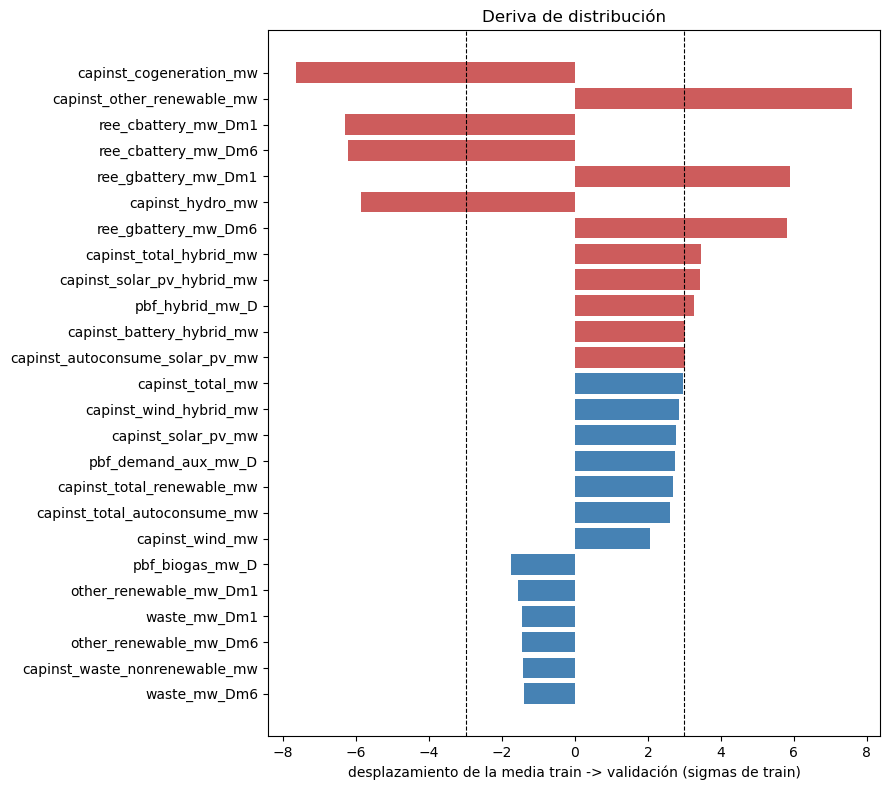

In [21]:
plt.figure(figsize=(9, 8))
top = deriva.head(25).iloc[::-1]
plt.barh(top.index, top.values,
         color=["indianred" if abs(v) > UMBRAL_DERIVA else "steelblue" for v in top.values])
plt.axvline(UMBRAL_DERIVA, ls="--", color="black", lw=0.8)
plt.axvline(-UMBRAL_DERIVA, ls="--", color="black", lw=0.8)
plt.xlabel("desplazamiento de la media train -> validación (sigmas de train)")
plt.title("Deriva de distribución")
plt.tight_layout()

## 6 · Separación de objetivo e inputs

`es_esios_D`, `es_esios_Dm1` y `es_esios_Dm6` son el precio en días anteriores. Son
features legítimas y potentísimas — `es_esios_D` es la persistencia, la referencia
contra la que se mide todo — pero se apartan del pool para que el ranking de la
sección 11 hable del resto. Si no, solo hablan ellas.

In [22]:
persistencia = [c for c in numericas if c.startswith("es_esios_")]
variables_input = [c for c in numericas if c not in persistencia]

print(f"Objetivo            : {TARGET}")
print(f"Persistencia        : {len(persistencia)}  {persistencia}")
print(f"Pool de candidatas  : {len(variables_input)}")
print(f"Categóricas         : {len(COLS_CATEGORICAS)}")

Objetivo            : target_price
Persistencia        : 3  ['es_esios_D', 'es_esios_Dm1', 'es_esios_Dm6']
Pool de candidatas  : 139
Categóricas         : 8


## 7 · Valores atípicos

Criterio de clase (`atipicosAmissing`): atípico solo si cumple **a la vez** `|z| > 3`
(o `|MAD| > 8` si es asimétrica) **y** queda fuera de `Q1 − 3·IQR` / `Q3 + 3·IQR`.

**No se aplica el tratamiento de clase.** En la tarea de elecciones los atípicos se
pasaban a *missing* y se imputaban; aquí una hora a 300 €/MWh en una ola de calor sin
viento es justo el caso que hay que acertar. Se diagnostica y se ordena.

,variable,tabla_origen,bloque,n_atipicos,pct_atipicos,asimetria,minimo
0,capdisp_coal_antracita_mw,esios_capacity_available,capacidad,15958,36.378143,2.555435,230.000
1,capinst_wind_hybrid_mw,esios_capacity_installed,capacidad,9574,21.825062,1.622419,0.000
2,capinst_solar_pv_hybrid_mw,esios_capacity_installed,capacidad,8807,20.076595,1.805939,0.000
3,capinst_battery_hybrid_mw,esios_capacity_installed,capacidad,8807,20.076595,1.801116,0.000
4,ree_ntc_impma,load_inter (NTC),prevision D+1,5830,13.290173,-3.505141,0.000
5,capinst_total_hybrid_mw,esios_capacity_installed,capacidad,5160,11.762829,1.599628,11.580
6,pbf_hybrid_mw_D,esios_pbf_gen,programa PBF,4536,10.340347,3.995549,0.000
7,pbf_pumping_cons_mw_D,esios_pbf_gen,programa PBF,4435,10.110106,-2.004041,-4452.000
8,ntc_ma_exp_prev_mw,forecast,prevision D+1,3535,8.058449,-3.118824,0.000
9,ntc_ma_imp_prev_mw,forecast,prevision D+1,3427,7.812251,-4.555976,0.000


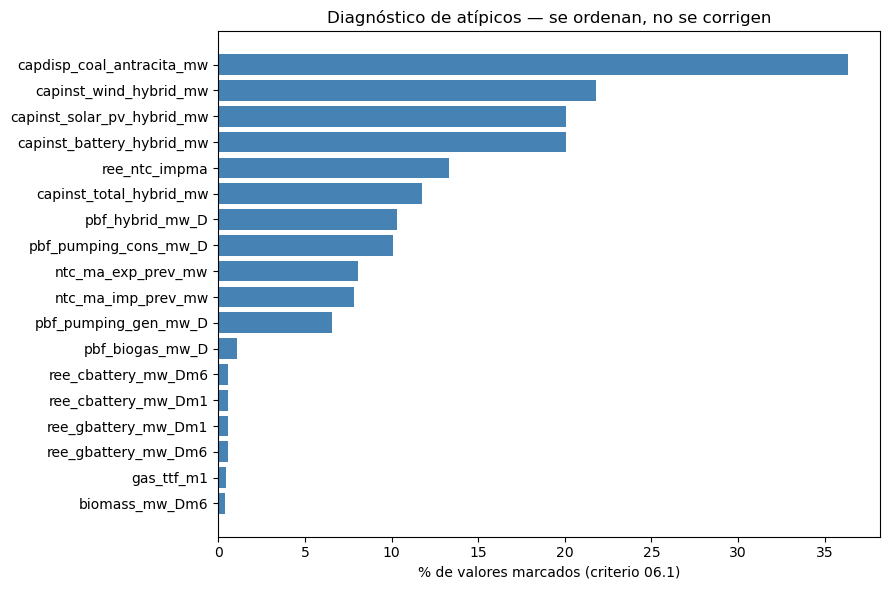

In [23]:
atipicos = dep.diagnostico_atipicos(datos[TRAIN], variables_input + [TARGET])
display(con_origen(atipicos[atipicos["n_atipicos"] > 0]).head(20))

top = atipicos[atipicos["n_atipicos"] > 0].head(18).iloc[::-1]
if len(top):
    plt.figure(figsize=(9, 6))
    plt.barh(top["variable"], top["pct_atipicos"],
             color=["indianred" if v == TARGET else "steelblue" for v in top["variable"]])
    plt.xlabel("% de valores marcados (criterio 06.1)")
    plt.title("Diagnóstico de atípicos — se ordenan, no se corrigen")
    plt.tight_layout()

## 8 · Valores perdidos

Tras la regla de la sección 5.1 debería quedar muy poco, y lo que quede tiene que tener
nombre y apellidos.

In [24]:
prop = datos[variables_input].isna().mean()
con_nulos = prop[prop > 0].sort_values(ascending=False)

print(f"Variables con algún perdido: {len(con_nulos)} de {len(variables_input)}")
print(f"Celdas nulas: {datos[variables_input].isna().sum().sum():,} "
      f"({datos[variables_input].isna().mean().mean() * 100:.3f}% del pool)\n")
tabla_nulos = con_origen(
    con_nulos.rename("pct_nulos").mul(100).round(2).reset_index()
      .rename(columns={"index": "variable"}))
display(tabla_nulos.head(20))
print()
print("Perdidos agrupados por tabla de origen:")
print(tabla_nulos.groupby("tabla_origen")["pct_nulos"].agg(
    columnas="size", peor="max").round(2).to_string())

Variables con algún perdido: 57 de 139
Celdas nulas: 87,005 (1.085% del pool)



,variable,tabla_origen,bloque,pct_nulos
0,pbf_net_flow_ma_mw_D,esios_pbf_load_inter,programa PBF,54.42
1,ntc_ma_imp_prev_mw,forecast,prevision D+1,12.74
2,ntc_fr_exp_prev_mw,forecast,prevision D+1,12.74
3,ntc_pt_imp_prev_mw,forecast,prevision D+1,12.74
4,ntc_pt_exp_prev_mw,forecast,prevision D+1,12.74
5,ntc_ma_exp_prev_mw,forecast,prevision D+1,12.74
6,ntc_fr_imp_prev_mw,forecast,prevision D+1,12.74
7,pbf_net_flow_ad_mw_D,esios_pbf_load_inter,programa PBF,12.36
8,gen_peninsular_mw_Dm6,generation (real D-1/D-6),real desfasado,0.36
9,entsoe_load_Dm6,generation (real D-1/D-6),real desfasado,0.36



Perdidos agrupados por tabla de origen:
                           columnas   peor
tabla_origen                              
commodities                       3   0.17
era5_weather_agg                 14   0.14
esios_pbf_gen                     5   0.26
esios_pbf_load_inter             10  54.42
forecast                          7  12.74
generation (real D-1/D-6)        18   0.36


count    57689.000000
mean         0.010850
std          0.020219
min          0.000000
25%          0.000000
50%          0.007194
75%          0.007194
max          0.402878

Filas con >50% de campos perdidos: 0

No se elimina ninguna fila: en serie temporal el hueco es información, y
borrar filas descuadra los días de 24 horas que el encoder espera.


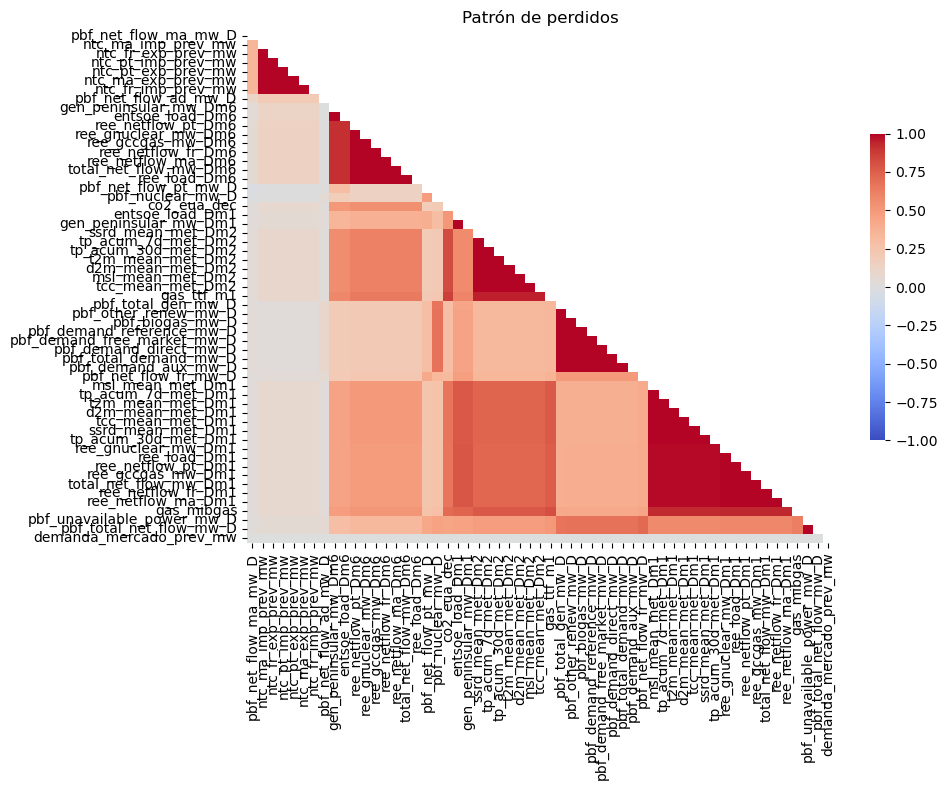

In [25]:
datos["prop_missings"] = datos[variables_input].isna().mean(axis=1)
print(datos["prop_missings"].describe().to_string())
print(f"\nFilas con >50% de campos perdidos: {(datos['prop_missings'] > 0.5).sum()}")
print()
print("No se elimina ninguna fila: en serie temporal el hueco es información, y")
print("borrar filas descuadra los días de 24 horas que el encoder espera.")

if len(con_nulos) > 1:
    corr_na = datos[list(con_nulos.index)].isna().corr()
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_na, cmap="coolwarm", center=0, vmin=-1, vmax=1,
                mask=np.triu(np.ones_like(corr_na, dtype=bool)),
                cbar_kws={"shrink": 0.6}, xticklabels=True, yticklabels=True)
    plt.title("Patrón de perdidos")
    plt.tight_layout()

### 8.1 · Cobertura: nulos que NO son huecos

Ocho columnas concentran casi todos los perdidos que quedan, y en todas el nulo
significa lo mismo: **la serie todavía no se publicaba**. No es un hueco a interpolar,
es una variable que no existe en la primera parte de la ventana.

Interpolarlas sería inventar; rellenarlas con cero, peor todavía (un 2020 sin comercio
con Marruecos). Se marcan y se dejan intactas: entran en la matriz `completa`, para
quien use modelos que toleran `NaN`, y quedan fuera de `nucleo` y `minima`.

In [26]:
UMBRAL_COBERTURA = 0.10          # más de un 10 % de nulos en train

nulos_train = datos.loc[TRAIN, variables_input].isna().mean()
baja_cobertura = nulos_train[nulos_train > UMBRAL_COBERTURA].index.tolist()

filas = []
for c in baja_cobertura:
    primer = datos.loc[datos[c].notna(), "fecha_objetivo"].min()
    por_anio = datos.groupby(datos["fecha_objetivo"].dt.year)[c].apply(
        lambda x: round(x.isna().mean() * 100, 1))
    filas.append({"variable": c, "pct_nulos_train": round(nulos_train[c] * 100, 1),
                  "primer_dato": primer.date(),
                  **{f"n{a}": v for a, v in por_anio.items() if a <= 2025}})
tabla_cob = con_origen(pd.DataFrame(filas).sort_values("pct_nulos_train", ascending=False))
display(tabla_cob)

for c in baja_cobertura:
    anotar("8.1", c, "cobertura insuficiente en train",
           f"{nulos_train[c] * 100:.1f}% de nulos; la serie empieza más tarde")
print(f"{len(baja_cobertura)} columnas marcadas. Se conservan en `completa`, fuera de las otras dos.")

,variable,tabla_origen,bloque,pct_nulos_train,primer_dato,n2020,n2021,n2022,n2023,n2024,n2025
6,pbf_net_flow_ma_mw_D,esios_pbf_load_inter,programa PBF,67.0,2021-02-16,100.0,98.6,60.6,45.7,30.2,15.5
0,ntc_fr_imp_prev_mw,forecast,prevision D+1,16.8,2020-11-01,83.3,0.0,0.0,0.0,0.4,0.0
2,ntc_pt_imp_prev_mw,forecast,prevision D+1,16.8,2020-11-01,83.3,0.0,0.0,0.0,0.4,0.0
1,ntc_fr_exp_prev_mw,forecast,prevision D+1,16.8,2020-11-01,83.3,0.0,0.0,0.0,0.4,0.0
3,ntc_pt_exp_prev_mw,forecast,prevision D+1,16.8,2020-11-01,83.3,0.0,0.0,0.0,0.4,0.0
4,ntc_ma_imp_prev_mw,forecast,prevision D+1,16.8,2020-11-01,83.3,0.0,0.0,0.0,0.4,0.0
5,ntc_ma_exp_prev_mw,forecast,prevision D+1,16.8,2020-11-01,83.3,0.0,0.0,0.0,0.4,0.0
7,pbf_net_flow_ad_mw_D,esios_pbf_load_inter,programa PBF,13.1,2020-01-02,24.5,19.4,5.6,6.3,9.6,2.4


8 columnas marcadas. Se conservan en `completa`, fuera de las otras dos.


## 9 · Imputación

Dos pasos, y el segundo es la regla del equipo: **la matriz sale sin un solo `NaN`**.

**9.1 — Interpolación temporal acotada a 3 horas.** Para los huecos cortos. Sustituye a
la mediana global de la metodología de clase, que en una serie horaria planta un valor
de las siete de la tarde a las cuatro de la mañana.

**9.2 — Lo que quede, a cero.** Con un matiz que conserva la información en vez de
tirarla: las columnas donde el relleno afecta a más del 1 % de train llevan un **testigo
`<columna>_era_nulo`**. Así el modelo puede distinguir "0 porque esa tecnología no
programó" de "0 porque la serie todavía no se publicaba" — que es justo la diferencia
entre las ocho columnas de la sección 8.1 y el resto. El cero entra, pero no borra el
rastro de por qué está ahí.

In [27]:
# ── 9.1 · huecos cortos: interpolación temporal ───────────────────────────
# El alcance es TODO lo que viaja como feature en las matrices, no solo el pool
# de candidatas: la persistencia (`es_esios_*`) se aparta del ranking en la
# sección 6 pero entra en las tres matrices, y los testigos de publicación del
# PBF traen NaN en las filas que el merge no encontró.
TESTIGOS_PBF = ["pbf_publicado_D", "pbf_completo_D"]
columnas_feature = [c for c in variables_input + persistencia + TESTIGOS_PBF
                    if c in datos.columns]
imputables = [c for c in columnas_feature if datos[c].isna().any()]
antes = datos[imputables].isna().sum()

aux = datos.set_index("ts")[imputables].interpolate(
    method="time", limit=3, limit_direction="both", limit_area="inside")
datos[imputables] = aux.to_numpy()

tras_interp = datos[imputables].isna().sum()
inf_interp = pd.DataFrame({"antes": antes, "tras_interpolar": tras_interp})
inf_interp["interpolados"] = inf_interp["antes"] - inf_interp["tras_interpolar"]
display(con_origen(inf_interp[inf_interp["interpolados"] > 0]
                   .sort_values("interpolados", ascending=False)).head(15))
print(f"Interpoladas {int(inf_interp['interpolados'].sum()):,} celdas. "
      f"Quedan {int(tras_interp.sum()):,}.")

,antes,tabla_origen,bloque,tras_interpolar,interpolados
pbf_net_flow_ma_mw_D,31394,esios_pbf_load_inter,programa PBF,23905,7489
pbf_net_flow_ad_mw_D,7130,esios_pbf_load_inter,programa PBF,6832,298
pbf_net_flow_pt_mw_D,172,esios_pbf_load_inter,programa PBF,103,69
pbf_nuclear_mw_D,150,esios_pbf_gen,programa PBF,111,39
pbf_net_flow_fr_mw_D,61,esios_pbf_load_inter,programa PBF,24,37
pbf_total_gen_mw_D,69,esios_pbf_gen,programa PBF,54,15
pbf_demand_reference_mw_D,68,esios_pbf_load_inter,programa PBF,54,14
pbf_demand_free_market_mw_D,68,esios_pbf_load_inter,programa PBF,54,14
pbf_biogas_mw_D,68,esios_pbf_gen,programa PBF,54,14
pbf_other_renew_mw_D,68,esios_pbf_gen,programa PBF,54,14


Interpoladas 8,391 celdas. Quedan 78,937.


In [28]:
# ── 9.2 · el resto a cero, con testigo ────────────────────────────────────
UMBRAL_TESTIGO = 0.01        # a partir de aquí la columna se acompaña de su bandera

pendientes = [c for c in columnas_feature if datos[c].isna().any()]

# Un testigo por PATRÓN de ausencia, no por columna. Las seis `ntc_*_prev_mw` faltan
# exactamente en las mismas filas: seis banderas idénticas sólo meten colinealidad
# perfecta en la matriz. Se agrupan por su patrón de nulos y cada grupo recibe una.
patrones, testigos = {}, []
for c in pendientes:
    if datos.loc[TRAIN, c].isna().mean() > UMBRAL_TESTIGO:
        patrones.setdefault(tuple(datos[c].isna().to_numpy().nonzero()[0]), []).append(c)

for cols_grupo in patrones.values():
    nombre = (f"{cols_grupo[0]}_era_nulo" if len(cols_grupo) == 1
              else f"{__import__('os').path.commonprefix(cols_grupo).rstrip('_') or 'grupo'}_era_nulo")
    datos[nombre] = datos[cols_grupo[0]].isna().astype(int)
    testigos.append(nombre)
    print(f"  testigo {nombre:34s} cubre {len(cols_grupo)} columna(s): "
          f"{cols_grupo if len(cols_grupo) <= 3 else cols_grupo[:3] + ['...']}")

de_columna_a_testigo = {c: n for n, g in zip(testigos, patrones.values()) for c in g}

filas = []
for c in pendientes:
    n = int(datos[c].isna().sum())
    frac_train = float(datos.loc[TRAIN, c].isna().mean())
    datos[c] = datos[c].fillna(0.0)
    filas.append({"variable": c, "celdas_a_cero": n,
                  "pct_train": round(frac_train * 100, 2),
                  "testigo": de_columna_a_testigo.get(c, "")})
    anotar("9.2", c, "NaN -> 0",
           f"{n} celdas; testigo={de_columna_a_testigo.get(c, 'ninguno')}")

tabla_cero_final = con_origen(pd.DataFrame(filas).sort_values("celdas_a_cero", ascending=False))
display(tabla_cero_final.head(20))
print()
print(f"{len(pendientes)} columnas rellenadas a cero · "
      f"{int(tabla_cero_final['celdas_a_cero'].sum()):,} celdas · "
      f"{len(testigos)} testigos creados")
print()
print("Por tabla de origen:")
print(tabla_cero_final.groupby("tabla_origen")["celdas_a_cero"].agg(
    columnas="size", celdas="sum").to_string())

  testigo ntc_era_nulo                       cubre 6 columna(s): ['ntc_fr_imp_prev_mw', 'ntc_fr_exp_prev_mw', 'ntc_pt_imp_prev_mw', '...']
  testigo pbf_net_flow_ma_mw_D_era_nulo      cubre 1 columna(s): ['pbf_net_flow_ma_mw_D']
  testigo pbf_net_flow_ad_mw_D_era_nulo      cubre 1 columna(s): ['pbf_net_flow_ad_mw_D']


,variable,tabla_origen,bloque,celdas_a_cero,pct_train,testigo
39,pbf_net_flow_ma_mw_D,esios_pbf_load_inter,programa PBF,23905,53.69,pbf_net_flow_ma_mw_D_era_nulo
1,ntc_fr_exp_prev_mw,forecast,prevision D+1,7345,16.74,ntc_era_nulo
2,ntc_pt_imp_prev_mw,forecast,prevision D+1,7345,16.74,ntc_era_nulo
3,ntc_pt_exp_prev_mw,forecast,prevision D+1,7345,16.74,ntc_era_nulo
0,ntc_fr_imp_prev_mw,forecast,prevision D+1,7345,16.74,ntc_era_nulo
5,ntc_ma_exp_prev_mw,forecast,prevision D+1,7345,16.74,ntc_era_nulo
4,ntc_ma_imp_prev_mw,forecast,prevision D+1,7345,16.74,ntc_era_nulo
40,pbf_net_flow_ad_mw_D,esios_pbf_load_inter,programa PBF,6832,12.50,pbf_net_flow_ad_mw_D_era_nulo
16,entsoe_load_Dm6,generation (real D-1/D-6),real desfasado,197,0.38,
21,gen_peninsular_mw_Dm6,generation (real D-1/D-6),real desfasado,197,0.38,



61 columnas rellenadas a cero · 78,937 celdas · 3 testigos creados

Por tabla de origen:
                                   columnas  celdas
tabla_origen                                       
DERIVADA (testigo de publicacion)         2      48
commodities                               3     210
era5_weather_agg                         14     854
esios_pbf_gen                             5     297
esios_pbf_load_inter                     10   31158
forecast                                  6   44070
generation (real D-1/D-6)                18    2060
spot_price (lag)                          3     240


In [29]:
variables_input = variables_input + testigos
restantes = int(datos[columnas_feature + testigos].isna().sum().sum())
print(f"NaN restantes en todas las columnas-feature: {restantes}")
assert restantes == 0, "la matriz debe salir sin nulos"
print("La matriz sale sin un solo NaN.")
registrar("9 · imputación a cero", datos, [TARGET] + numericas + COLS_CATEGORICAS + testigos)

NaN restantes en todas las columnas-feature: 0
La matriz sale sin un solo NaN.


,etapa,filas,columnas,celdas_nulas,filas_con_nulo
0,0 · carga v04,57689,220,112026,17012
1,2.1 · fuera PDBC,57689,118,49674,7486
2,2.2 · +PBF horario,57689,150,90048,33879
3,2.3 · +ERA5 horario,57689,170,91408,33882
4,2.4 · apagón marcado,57689,170,91408,33882
5,3 · tipado,57689,164,91346,33882
6,5.1 · NULL tecnología -> 0,57689,164,87345,33882
7,5.2 · constantes,57689,155,87266,33882
8,5.3 · colinealidad exacta,57689,153,87266,33882
9,5.4 · racha de viento,57689,151,87266,33882


## 10 · Redundancia

Cada par muy correlacionado es una elección pendiente. Con 219 columnas de partida la
redundancia es masiva y en parte deliberada (dos fuentes para la misma magnitud, un
total que es suma de sus partes). Listarla hace que la elección sea explícita.

In [30]:
redundancia = dep.bloques_correlacion(datos[TRAIN], variables_input, umbral=0.95)
red_anotada = con_origen_pares(redundancia)
print(f"Pares con |r| >= 0.95: {len(redundancia)}")
print(f"  dentro de la MISMA tabla : {red_anotada['mismo_origen'].sum()}  (duplicidad de la fuente)")
print(f"  entre tablas DISTINTAS   : {(~red_anotada['mismo_origen']).sum()}  (dos fuentes miden lo mismo)")
display(red_anotada.head(30).round(4))

Pares con |r| >= 0.95: 40
  dentro de la MISMA tabla : 38  (duplicidad de la fuente)
  entre tablas DISTINTAS   : 2  (dos fuentes miden lo mismo)


,var_a,var_b,correlacion,origen_a,origen_b,mismo_origen
0,capinst_total_nonrenewable_mw,capinst_coal_mw,1.0000,esios_capacity_installed,esios_capacity_installed,True
1,ree_load_Dm6,entsoe_load_Dm6,0.9993,generation (real D-1/D-6),generation (real D-1/D-6),True
2,ree_load_Dm1,entsoe_load_Dm1,0.9992,generation (real D-1/D-6),generation (real D-1/D-6),True
3,capinst_total_renewable_mw,capinst_solar_pv_mw,0.9987,esios_capacity_installed,esios_capacity_installed,True
4,tp_acum_30d_met_Dm1,tp_acum_30d_met_Dm2,0.9948,era5_weather_agg,era5_weather_agg,True
5,capinst_total_mw,capinst_solar_pv_mw,0.9944,esios_capacity_installed,esios_capacity_installed,True
6,capinst_total_autoconsume_mw,capinst_solar_pv_mw,0.9935,esios_capacity_installed,esios_capacity_installed,True
7,demanda_prev_mw,demanda_mercado_prev_mw,0.9926,forecast,forecast,True
8,ssrd_mean_met_Dm1,ssrd_mean_met_Dm2,0.9919,era5_weather_agg,era5_weather_agg,True
9,capinst_solar_pv_hybrid_mw,capinst_battery_hybrid_mw,0.9912,esios_capacity_installed,esios_capacity_installed,True


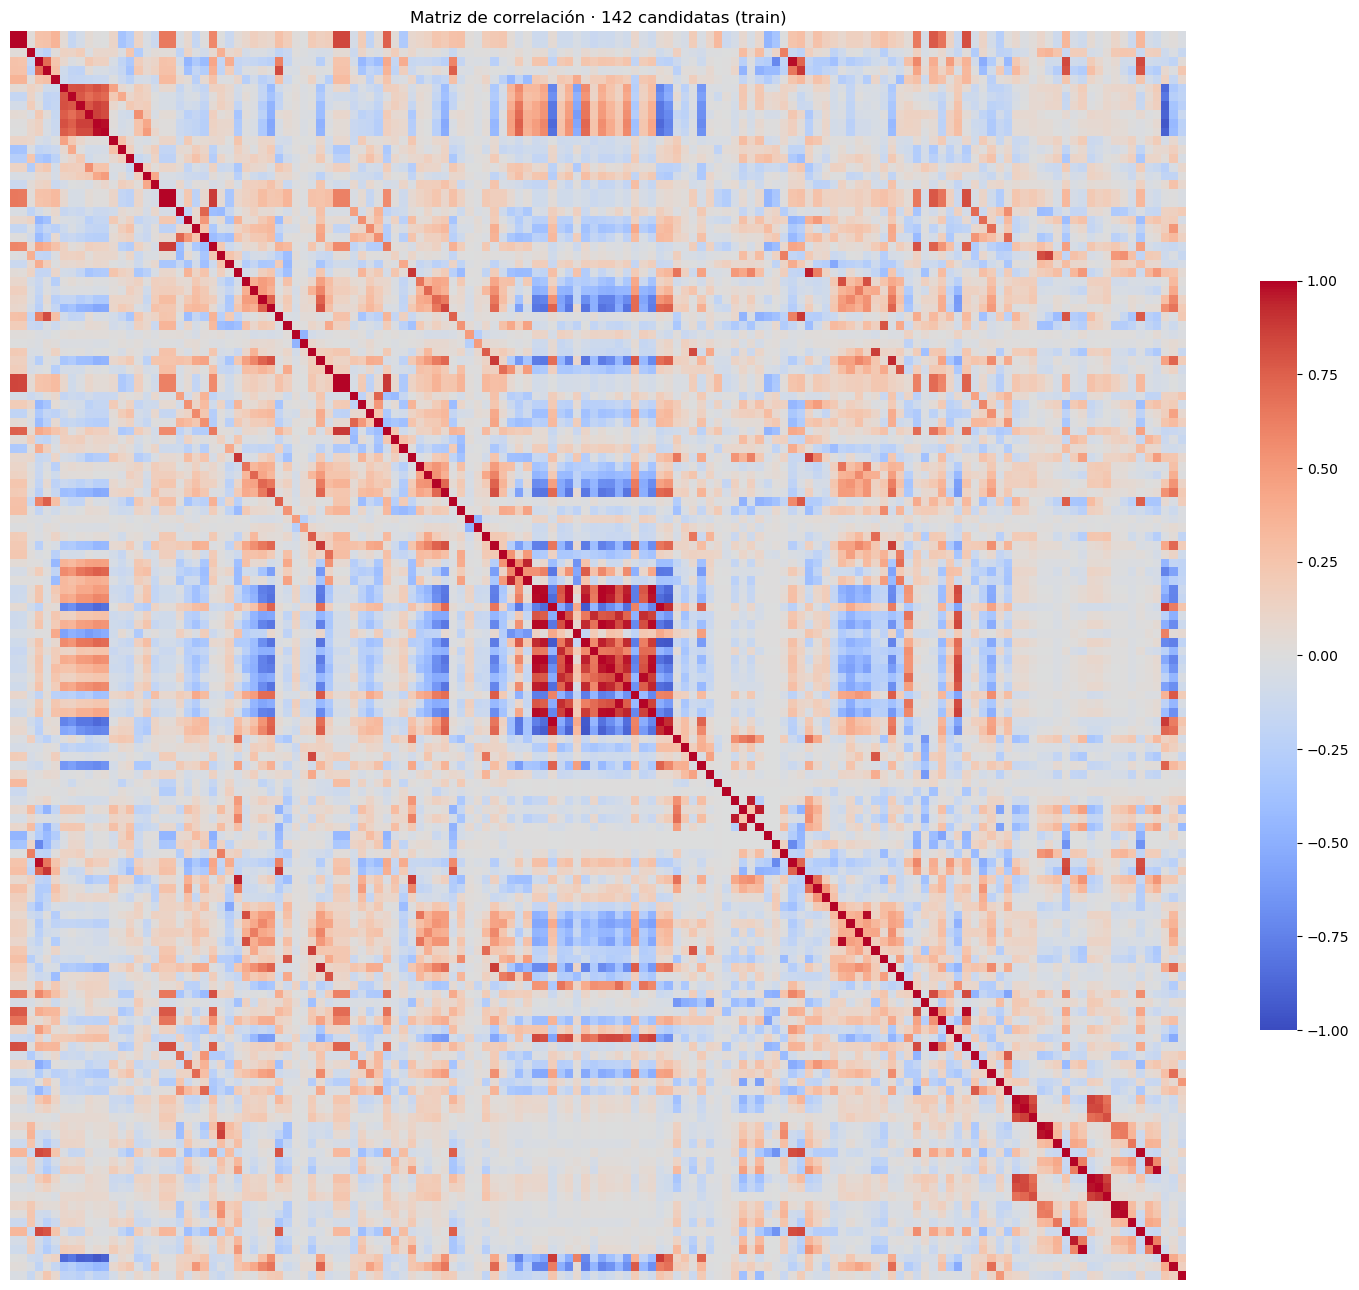

In [31]:
cols_corr = [c for c in variables_input if datos.loc[TRAIN, c].notna().mean() > 0.9]
plt.figure(figsize=(15, 13))
sns.heatmap(datos.loc[TRAIN, cols_corr].corr(), cmap="coolwarm", center=0, vmin=-1, vmax=1,
            cbar_kws={"shrink": 0.6}, xticklabels=False, yticklabels=False)
plt.title(f"Matriz de correlación · {len(cols_corr)} candidatas (train)")
plt.tight_layout()

## 11 · Importancia frente al objetivo

El gráfico de V de Cramer de la sección 7.2 de la tarea de clase. Tres medidas, porque
discrepar es informativo: Pearson (lineal), Spearman (monótona) y V de Cramer
(asociación sobre quintiles, capta formas de U o escalón).

Mide **asociación, no aporte incremental**: una variable con V de Cramer alto puede no
sumar nada si otra ya lleva esa información. Se lee junto a la sección 10.

In [32]:
ranking = dep.ranking_asociacion(datos[TRAIN], variables_input, TARGET)
display(con_origen(ranking).head(30).round(3))
print("Mejor V de Cramer por tabla de origen:")
print(con_origen(ranking).groupby("tabla_origen")["v_cramer"].agg(
    columnas="size", mejor="max", mediana="median").round(3)
    .sort_values("mejor", ascending=False).to_string())

,variable,tabla_origen,bloque,pearson,spearman,v_cramer,n_pares,abs_pearson
0,pbf_coal_mw_D,esios_pbf_gen,programa PBF,0.564,0.522,0.552,43867,0.564
1,capdisp_coal_antracita_mw,esios_capacity_available,capacidad,-0.334,-0.382,0.495,43867,0.334
2,capinst_coal_mw,esios_capacity_installed,capacidad,-0.288,-0.159,0.494,43867,0.288
3,gas_mibgas,commodities,combustibles,0.732,0.752,0.488,43867,0.732
4,gas_ttf_m1,commodities,combustibles,0.634,0.736,0.464,43867,0.634
5,ntc_ma_imp_prev_mw,forecast,prevision D+1,0.397,0.434,0.459,43867,0.397
6,ntc_ma_exp_prev_mw,forecast,prevision D+1,0.381,0.425,0.452,43867,0.381
7,capinst_hydro_mw,esios_capacity_installed,capacidad,-0.595,-0.548,0.452,43867,0.595
8,capinst_total_autoconsume_mw,esios_capacity_installed,capacidad,-0.033,0.170,0.415,43867,0.033
9,capinst_autoconsume_solar_pv_mw,esios_capacity_installed,capacidad,-0.130,0.170,0.413,43867,0.130


Mejor V de Cramer por tabla de origen:
                                  columnas  mejor  mediana
tabla_origen                                              
esios_pbf_gen                           18  0.552    0.179
esios_capacity_available                 5  0.495    0.139
esios_capacity_installed                17  0.494    0.412
commodities                              3  0.488    0.464
forecast                                12  0.459    0.249
generation (real D-1/D-6)               42  0.302    0.137
load_inter (NTC)                         6  0.224    0.082
esios_pbf_load_inter                    12  0.193    0.103
CALENDARIO (calculado)                   8  0.180    0.104
era5_weather_agg                        18  0.158    0.089
DERIVADA (testigo de imputacion)         1    NaN      NaN


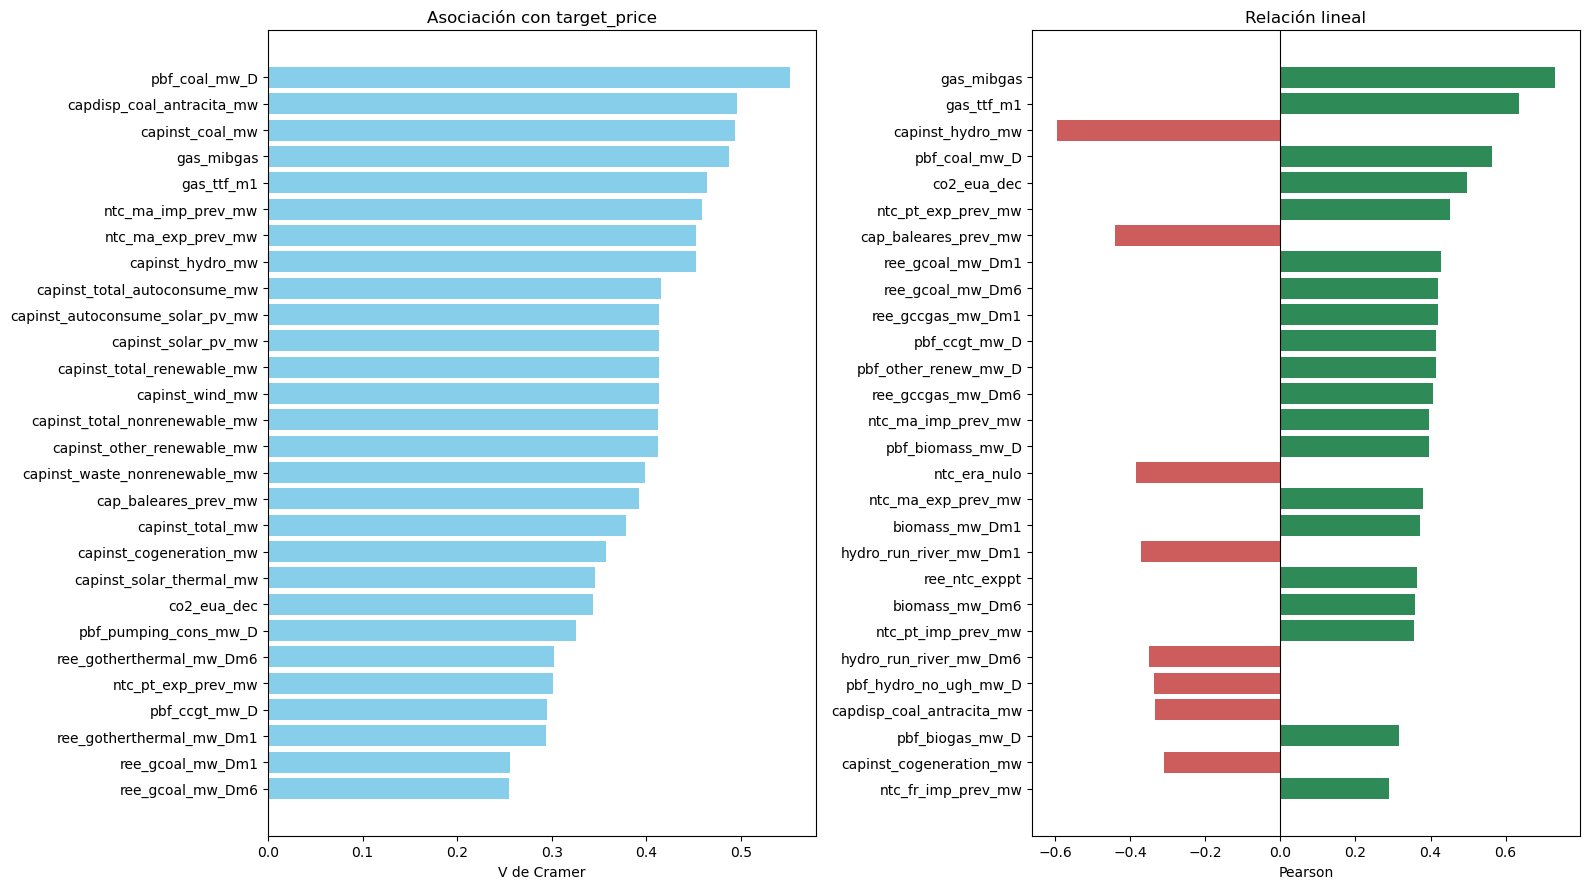

In [33]:
fig, ax = plt.subplots(1, 2, figsize=(16, 9))
top = ranking.dropna(subset=["v_cramer"]).head(28).iloc[::-1]
ax[0].barh(top["variable"], top["v_cramer"], color="skyblue")
ax[0].set_xlabel("V de Cramer"); ax[0].set_title("Asociación con target_price")
top_p = ranking.sort_values("abs_pearson", ascending=False).head(28).iloc[::-1]
ax[1].barh(top_p["variable"], top_p["pearson"],
           color=["indianred" if v < 0 else "seagreen" for v in top_p["pearson"]])
ax[1].axvline(0, color="black", lw=0.8)
ax[1].set_xlabel("Pearson"); ax[1].set_title("Relación lineal")
plt.tight_layout()

In [34]:
# ¿Cuánto aporta el bloque PBF nuevo?
pbf_rank = ranking[ranking["variable"].str.startswith("pbf_")]
print(f"Columnas PBF en el pool: {len(pbf_rank)}")
print(f"  mejor V de Cramer: {pbf_rank['v_cramer'].max():.3f} "
      f"({pbf_rank.loc[pbf_rank['v_cramer'].idxmax(), 'variable']})")
print(f"  posición de la mejor en el ranking global: "
      f"{ranking.index[ranking['variable'] == pbf_rank.loc[pbf_rank['v_cramer'].idxmax(), 'variable']][0] + 1}"
      f" de {len(ranking)}")
print()
display(pbf_rank.head(12).round(3))

Columnas PBF en el pool: 30
  mejor V de Cramer: 0.552 (pbf_coal_mw_D)
  posición de la mejor en el ranking global: 1 de 142



,variable,pearson,spearman,v_cramer,n_pares,abs_pearson
0,pbf_coal_mw_D,0.564,0.522,0.552,43867,0.564
21,pbf_pumping_cons_mw_D,0.273,0.307,0.325,43867,0.273
24,pbf_ccgt_mw_D,0.414,0.479,0.295,43867,0.414
28,pbf_other_renew_mw_D,0.413,0.380,0.255,43867,0.413
37,pbf_biomass_mw_D,0.395,0.370,0.242,43867,0.395
40,pbf_cogen_mw_D,0.046,-0.037,0.229,43867,0.046
42,pbf_biogas_mw_D,0.316,0.307,0.227,43867,0.316
45,pbf_hydro_no_ugh_mw_D,-0.336,-0.405,0.222,43867,0.336
52,pbf_net_flow_ma_mw_D,0.029,-0.067,0.193,43867,0.029
53,pbf_demand_aux_mw_D,-0.115,-0.027,0.193,43867,0.115


## 12 · Matrices candidatas

Tres, con criterios distintos y explícitos:

| Matriz | Criterio | Para qué |
|---|---|---|
| **completa** | todo lo que sobrevive a las secciones 5 y 9 | árboles y modelos que toleran redundancia |
| **nucleo** | sin redundantes (\|r\| ≥ 0,95) y sin deriva > 3σ | Seq2Seq y lineales; la apuesta por defecto |
| **minima** | top 25 por V de Cramer, ya sin redundancia | baselines rápidos y control de sobreajuste |

Las tres llevan el objetivo, la persistencia, las categóricas de calendario y las
banderas del apagón. Las tres conservan las filas de 2026 sin que ninguna decisión las
haya mirado.

In [35]:
# De cada par redundante sobrevive el de mayor V de Cramer.
vc = ranking.set_index("variable")["v_cramer"].to_dict()
descartar_red = set()
for _, r in redundancia.iterrows():
    a, b = r["var_a"], r["var_b"]
    if a in descartar_red or b in descartar_red:
        continue
    descartar_red.add(b if vc.get(a, 0) >= vc.get(b, 0) else a)

print(f"Descartadas por redundancia: {len(descartar_red)}")
print(f"Descartadas por deriva > {UMBRAL_DERIVA}σ: {len(muy_derivadas)}")
print(f"Descartadas por cobertura: {len(baja_cobertura)}")
nucleo_inputs = [c for c in variables_input
                 if c not in descartar_red and c not in muy_derivadas
                 and c not in baja_cobertura
                 and not (c.endswith('_era_nulo')
                          and c[:-len('_era_nulo')] in baja_cobertura)]
print(f"\nPool completo : {len(variables_input)}")
print(f"Pool núcleo   : {len(nucleo_inputs)}")

minima_inputs = [c for c in ranking["variable"] if c in nucleo_inputs][:25]
print(f"Pool mínima   : {len(minima_inputs)}")

Descartadas por redundancia: 26
Descartadas por deriva > 3.0σ: 12
Descartadas por cobertura: 8

Pool completo : 142
Pool núcleo   : 100
Pool mínima   : 25


In [36]:
COMUNES = COLS_CONTROL + [TARGET] + persistencia + COLS_CATEGORICAS + COLS_BANDERA
SALIDA_DIR.mkdir(parents=True, exist_ok=True)

MATRICES = {
    "completa": variables_input,
    "nucleo": nucleo_inputs,
    "minima": minima_inputs,
}

resumen = []
for nombre, inputs in MATRICES.items():
    cols = list(dict.fromkeys([c for c in COMUNES + inputs if c in datos.columns]))
    m = datos[cols].copy()
    ruta = SALIDA_DIR / f"matriz_{nombre}.parquet"
    m.to_parquet(ruta, index=False)
    meta = {
        "nombre": nombre,
        "origen": ORIGEN.name,
        "bloque_pdbc": "retirado",
        "bloque_pbf": "esios_pbf_gen + esios_pbf_load_inter, horario, alineamiento D",
        "filas": int(len(m)), "columnas": int(m.shape[1]),
        "n_inputs": len(inputs),
        "train_end": "2024-12-31", "val_end": "2025-12-31",
        "apagon": "conservado y marcado (dia_apagon, ventana_pisa_apagon)",
        "nulos_restantes_inputs": int(m[inputs].isna().sum().sum()),
        "imputacion": "huecos <=3h interpolados; el resto a cero con testigo *_era_nulo",
        "catalogo_columnas": f"matriz_{nombre}_columnas.csv",
        "origenes": resumen_origen(cols).set_index("tabla_origen")["columnas"].to_dict(),
        "aviso": ("target_contrafactual es NaN por diseño fuera de los 9 días del "
                  "apagón: NO hacer dropna() sobre la matriz entera, solo sobre las "
                  "columnas de entrada."),
    }
    ruta.with_suffix(".meta.json").write_text(
        json.dumps(meta, indent=2, ensure_ascii=False), encoding="utf-8")
    # Catalogo de procedencia junto a cada matriz: quien la abra sabe de que tabla
    # sale cada columna sin tener que volver al notebook.
    catalogo(cols).to_csv(SALIDA_DIR / f"matriz_{nombre}_columnas.csv",
                          index=False, encoding="utf-8")
    resumen.append(meta)
    print(f"  {nombre:9s} -> {ruta.name:26s} {len(m):,} x {m.shape[1]}  nulos en inputs: {meta['nulos_restantes_inputs']:,}")

print()
print("AVISO: `target_contrafactual` vale NaN en todas las filas que no son del")
print("apagón -- es una columna de diagnóstico, no una feature. Un dropna() sobre")
print("la matriz entera dejaría 216 filas. Filtrar solo por las columnas de entrada.")
pd.DataFrame(resumen)[["nombre", "columnas", "n_inputs", "nulos_restantes_inputs"]]

  completa  -> matriz_completa.parquet    57,689 x 163  nulos en inputs: 0


  nucleo    -> matriz_nucleo.parquet      57,689 x 121  nulos en inputs: 0
  minima    -> matriz_minima.parquet      57,689 x 46  nulos en inputs: 0

AVISO: `target_contrafactual` vale NaN en todas las filas que no son del
apagón -- es una columna de diagnóstico, no una feature. Un dropna() sobre
la matriz entera dejaría 216 filas. Filtrar solo por las columnas de entrada.


,nombre,columnas,n_inputs,nulos_restantes_inputs
0,completa,163,142,0
1,nucleo,121,100,0
2,minima,46,25,0


In [37]:
# Bitácora de descartes: el documento que va a la memoria.
bit = con_origen(pd.DataFrame(bitacora), posicion=2)
ruta_bit = SALIDA_DIR / "bitacora_depuracion.csv"
bit.to_csv(ruta_bit, index=False, encoding="utf-8")
print(f"Bitácora -> {ruta_bit.relative_to(REPO)}  ({len(bit)} entradas)")
print()
print(bit.groupby(["seccion", "motivo"]).size().rename("columnas").to_string())
print()
print("Descartes por tabla de origen:")
print(bit.groupby("tabla_origen").size().rename("columnas")
        .sort_values(ascending=False).to_string())

Bitácora -> data\matrices\bitacora_depuracion.csv  (225 entradas)

seccion  motivo                         
2.1      bloque PDBC retirado               102
5.1      NULL -> 0                           41
5.2      constante en train                   7
         cuasi-constante en train             2
5.3      colinealidad exacta                  2
5.4      sin equivalente en produccion        2
8.1      cobertura insuficiente en train      8
9.2      NaN -> 0                            61

Descartes por tabla de origen:
tabla_origen
esios_pdbc_gen (RETIRADO)            102
generation (real D-1/D-6)             38
era5_weather_agg                      22
esios_pbf_gen                         21
forecast                              14
esios_pbf_load_inter                  12
esios_capacity_installed               6
commodities                            3
spot_price (lag)                       3
DERIVADA (testigo de publicacion)      2
CALENDARIO (calculado)                 1
esios_capaci

In [38]:
print("Composición de cada matriz por bloque de origen:")
comp = pd.concat({n: resumen_origen(
    [c for c in COMUNES + i if c in datos.columns]).set_index("tabla_origen")["columnas"]
    for n, i in MATRICES.items()}, axis=1).fillna(0).astype(int)
display(comp)

control = registrar("12 · matriz completa", datos, [TARGET] + variables_input + COLS_CATEGORICAS)
control["nulas_dif"] = control["celdas_nulas"].diff().fillna(0).astype(int)
control["cols_dif"] = control["columnas"].diff().fillna(0).astype(int)
control

Composición de cada matriz por bloque de origen:


,completa,nucleo,minima
tabla_origen,,,
CALENDARIO (calculado),15,13,7
esios_capacity_installed,17,5,5
esios_capacity_available,5,5,1
commodities,3,3,3
CLAVE,5,5,5
era5_weather_agg,18,11,0
spot_price (TARGET),1,1,1
DERIVADA (depuracion),3,3,3
DERIVADA (testigo de publicacion),2,2,2


,etapa,filas,columnas,celdas_nulas,filas_con_nulo,nulas_dif,cols_dif
0,0 · carga v04,57689,220,112026,17012,0,0
1,2.1 · fuera PDBC,57689,118,49674,7486,-62352,-102
2,2.2 · +PBF horario,57689,150,90048,33879,40374,32
3,2.3 · +ERA5 horario,57689,170,91408,33882,1360,20
4,2.4 · apagón marcado,57689,170,91408,33882,0,0
5,3 · tipado,57689,164,91346,33882,-62,-6
6,5.1 · NULL tecnología -> 0,57689,164,87345,33882,-4001,0
7,5.2 · constantes,57689,155,87266,33882,-79,-9
8,5.3 · colinealidad exacta,57689,153,87266,33882,0,-2
9,5.4 · racha de viento,57689,151,87266,33882,0,-2


### Comprobación del protocolo

Lo último antes de cerrar: verificar que ninguna decisión miró 2026.

In [39]:
comprobaciones = {
    "descriptivos calculados sobre": "train",
    "deriva medida contra": "validation (2025)",
    "ranking y redundancia sobre": "train",
    "umbral de constantes sobre": "train",
}
for k, v in comprobaciones.items():
    print(f"  {k:34s} {v}")

n26 = int(TEST.sum())
print(f"\nFilas de 2026 en los ficheros: {n26:,} (viajan, pero no se han leído)")
print(f"Split de las tres matrices: train <= 2024-12-31 · validation 2025 · test 2026")

falta = set(pd.date_range(APAGON_INI, APAGON_FIN).date) - set(
    datos.loc[datos["dia_apagon"] == 1, "fecha_objetivo"].dt.date)
print(f"\nDías del apagón ausentes: {len(falta)}  "
      f"-> validación 2025 completa: {'SÍ' if not falta else 'NO'}")

  descriptivos calculados sobre      train
  deriva medida contra               validation (2025)
  ranking y redundancia sobre        train
  umbral de constantes sobre         train

Filas de 2026 en los ficheros: 5,063 (viajan, pero no se han leído)
Split de las tres matrices: train <= 2024-12-31 · validation 2025 · test 2026

Días del apagón ausentes: 0  -> validación 2025 completa: SÍ


## Qué queda abierto

1. **`ERA5_MODO` admite un valor que es fuga.** El constructor permite `"perfecto"`, que
   mete el tiempo real del día D+1 para la ablación de cota superior. Este notebook usa
   solo el modo `lag`, pero conviene que el equipo sepa que ese flag existe antes de
   cerrar modelos el domingo.

2. **El alineamiento `_D` del PBF** está por confirmar con el equipo. El notebook usa el
   PBF del propio día D (disponible a las 12:00 de D, publicado a las 13:45 de D-1);
   `bloque_para_matriz(pbf, alineamiento="Dm1")` da la versión conservadora.

3. **Los días del apagón siguen dentro de validación.** Es deliberado: así 2025 está
   completo, como pide el protocolo. Quien evalúe decide si los excluye, y tiene
   `dia_apagon`, `ventana_pisa_apagon` y `target_contrafactual` para hacerlo con criterio.